In [46]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.gridspec import GridSpec

import warnings
warnings.filterwarnings('ignore')

# Extent:

In [47]:
extent = [-120, -73, 18.5, 52.5]

# Mask for dataset to exclude HI, AK, PR, etc. 
lat_min, lat_max = 24.5, 49.5
lon_min, lon_max = -125.0, -66.9

# Projection info
proj= ccrs.LambertConformal()
PC = ccrs.PlateCarree()

In [48]:
ds_hail = xr.open_dataset('/home/z2034747/Research/Datasets/P_Per/pper_hail_1979_2023.nc')
ds_hail = ds_hail.assign_coords(lon= ds_hail.lon, lat= ds_hail.lat)
ds_hail = ds_hail['p_perfect_hail'].where((ds_hail.lon >= lon_min) & (ds_hail.lon <= lon_max) & (ds_hail.lat >= lat_min) & (ds_hail.lat <= lat_max), drop= True)

som_ds = xr.open_dataset('/home/scratch/peldridge/pper_hail_by_node.nc')
som_ds = som_ds.assign_coords(lon= ds_hail.lon, lat= ds_hail.lat)
som_ds = som_ds['p_perfect_hail'].where((som_ds.lon >= lon_min) & (som_ds.lon <= lon_max) & (som_ds.lat >= lat_min) & (som_ds.lat <= lat_max), drop= True)


lats = ds_hail.lat.values
lons = ds_hail.lon.values

counts = len(ds_hail.time)

# Colorbars:


In [49]:
# Frequency of Exceedance:
foe_colors = ['#ffffb2','#fed976','#feb24c','#fd8d3c','#f03b20']
foe_15 = [1, 2, 3, 4, 5]
foe_5 = [1, 2, 4, 6, 8]

# Average:
mean_colors = ['#ffffb2','#fed976','#feb24c','#fd8d3c','#f03b20']
mean_levels = np.arange(0.5, 3.0, 0.5)

# PWAT: 
pwat_colors = ["#885c1e",
          "#a9834b",
          "#c1a779",
          "#d9cba7",
          "#f1f0d6",
          "#d6e6bd",
          "#bcdda4",
          "#a3d48d",
          "#89ca75",
          "#73c05d",
          "#50aa2d",
          "#1d4d06",
          "#6ea0ad",
          "#5a848d",
          "#44686d",
          "#2f4b4d",
          "#182b2b",
          "#666698",
          "#5a568d",
          "#4d4680",
          "#3f3575",
          "#7e7e00",
          "#9c9d00",
          "#bcbd00",
          "#dcdd00",
          "#fbfc00"]
pwat_levels = [i * 2.5 for i in range(27)]
pwat_colormap = ListedColormap(pwat_colors)

# Risk Colorbars:
risk_colors = [
    "#f4d71a",
    "#eb973d",
    "#bf4c78",
    "#5811a7",
    "#170f88",
    "#07d7f7",
    "#fd9cff"
]
risk_levels = [0.1, 0.5, 2.0, 5.0, 10.0, 15, 20]


alphabet = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M']

# SOM Preferences:


In [50]:
prefs = {'filename': "/home/scratch/peldridge/combine_z500_pwat.nc", 
         'var1': 'gh', 'var2': 'pwat', 'wlon': 220, 'elon': 305, 'nlat': 55, 'slat': 20, 
         'som_config': {'x': 5, 'y': 6, 'sigma': 1.5, 'random_seed': 42},
         'som_train': {'num_iteration': 10000, 'random_order': True, 'verbose': True}}

ncols, nrows = prefs['som_config']['x'], prefs['som_config']['y']
n = nrows * ncols

# Plotting Code:

In [51]:
def mask_dataset(ds):
    return ds.where((ds.lon >= lon_min) & (ds.lon <= lon_max) & (ds.lat >= lat_min) & (ds.lat <= lat_max), drop= True)


def plot_glakes(ax):
    shpfilename = shpreader.natural_earth(resolution='10m', category='physical', name='lakes')
    reader = shpreader.Reader(shpfilename)
    
    great_lakes_names = ['Lake Superior', 'Lake Michigan', 'Lake Huron', 'Lake Erie', 'Lake Ontario', 'Lake St. Clair']
    great_lakes_geoms = [record.geometry for record in reader.records() if record.attributes.get('name') in great_lakes_names]

    ax.add_geometries(great_lakes_geoms, linewidths= 0.2, facecolor= cfeature.COLORS['water'], crs=ccrs.PlateCarree(), edgecolor='black')
    
def plot_pper_contour(pper_data, title, colors, levels, ax= None, add_cbar= True): 
    
    # Calculate the Max:
    max_idx = np.nanargmax(pper_data)
    multi_index = np.unravel_index(max_idx, pper_data.shape)
    
    # Set up axes and decorations:
    if ax is None:
        ax = plt.subplot(1, 1, 1, projection= proj)
    ax.set_extent(extent)
    ax.add_feature(cfeature.STATES, linewidths= 0.2)
    ax.coastlines(linewidths= 0.5)
    ax.add_feature(cfeature.OCEAN)
    ax.add_feature(cfeature.LAND, facecolor= 'grey')
    plot_glakes(ax)
    
    # Plotting Data:
    contourf = ax.contourf(lons, lats, pper_data, colors= colors, levels= levels, extend= 'max', transform= PC)
    contour = ax.contour(lons, lats, pper_data, colors= 'k', linewidths= 0.5, levels= levels, transform= PC)
    
    # Plotting max point:
    ax.text(0.03, 0.05, f'MAX (*): {pper_data.max().values:.1f}%', transform= ax.transAxes, bbox= dict(facecolor= 'w', edgecolor= 'k', boxstyle= 'round'))
    ax.plot(pper_data['lon'].values[multi_index], pper_data['lat'].values[multi_index], markersize= 10, marker= '*', markerfacecolor= 'white', markeredgecolor= 'black', transform= ccrs.PlateCarree())
    
    # Colorbar:
    if add_cbar:
        cax = ax.inset_axes([0.0, -0.1, 0.65, 0.05])
        plt.colorbar(contourf, cax, orientation= 'horizontal', ticks= levels)

    # Finally, the title:
    ax.set_title(title, fontweight= 'bold')
    
    return ax, contourf


def plot_pper_stamps(pper_dataset, stat, threshold = None, colors = None, levels = None):
    
    
    
    # Set up axes:
    # fig = plt.figure(figsize= (4 * nrows, 4 * ncols))
    fig = plt.figure(figsize= (2.5* nrows, 2.5* ncols))
    gs = GridSpec(nrows + 1, ncols, height_ratios = [1] * nrows + [0.05], hspace= 0.05, wspace= 0.05)
    axes = [fig.add_subplot(gs[i // ncols, i % ncols], projection= ccrs.LambertConformal()) for i in range(n)]
    for j in range(0, nrows):
        for i in range(0, ncols):
            index = (j * ncols) + i
            data = pper_dataset.where((som_ds.som_x == i) & (som_ds.som_y == j), drop = True)
            
            if stat == 'mean':
                data = data.mean(dim= 'time')
            
            elif stat == 'percentile':
                data = data.quantile(threshold, dim= 'time')
                
            elif stat == 'max':
                data = data.max()
                
#             elif stat == 'stdanom':
#                 data = 

            elif stat == 'foe':
                counts = len(data.time.values)
                arr_15 = data.where(data >= threshold) * 0 + 1
                sum_15 = arr_15.sum(axis= 0)
                data = sum_15 / counts * 100
            ax = axes[index]
            ax, contourf = plot_pper_contour(data, None, colors, levels, ax, add_cbar= False)

            if j == 0: 
                ax.set_title(f'Col {alphabet[i]}')
            if i == 0: 
                ax.text(-0.15, 0.5, f'Row {j + 1}', va= 'center', ha= 'center', rotation= 'vertical', transform= ax.transAxes, fontsize= 12)

    fig.canvas.draw()

    pos_left = axes[(nrows - 1) * ncols].get_position()

    bottom_mid_ax = axes[(nrows - 1) * ncols + 2] 
    pos_mid = bottom_mid_ax.get_position()

    cbar_bottom = pos_left.y0 - 0.05 
    cbar_width = pos_mid.x1 - pos_left.x0 
    cbar_height = 0.02

    cax = fig.add_axes([pos_left.x0, cbar_bottom, cbar_width, cbar_height])
    
    if stat == 'mean':
        fig.colorbar(contourf, cax= cax, orientation= 'horizontal', label= 'Average Daily Risk (%)')
    elif stat == 'percentile': 
        fig.colorbar(contourf, cax= cax, orientation= 'horizontal', label= f'PPH Hail {int(100 * threshold)}th Percentile Risk (%)')
        
    elif stat == 'foe':
        fig.colorbar(contourf, cax= cax, orientation= 'horizontal', label= f'PPH Hail Frequency of Exceedence ≥ {threshold}%')
    return axes


# MEAN:

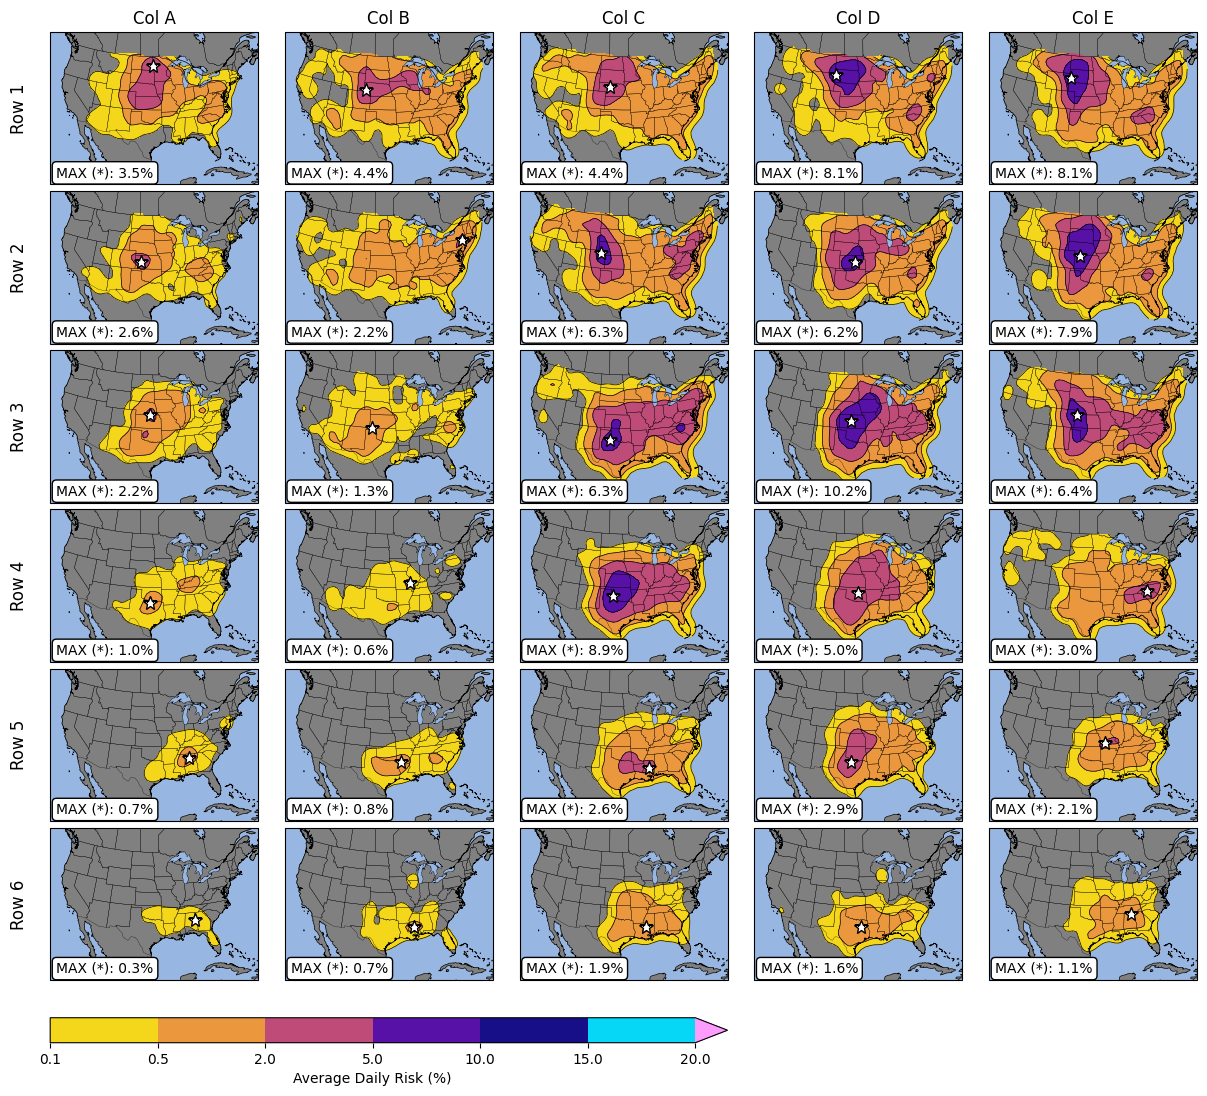

In [53]:
plot_pper_stamps(som_ds, 'mean', None, risk_colors, risk_levels)

plt.savefig('./Figures/mean_hail_nodes.png', dpi= 300, bbox_inches= 'tight')
plt.show()

# 50th PERCENTILE:

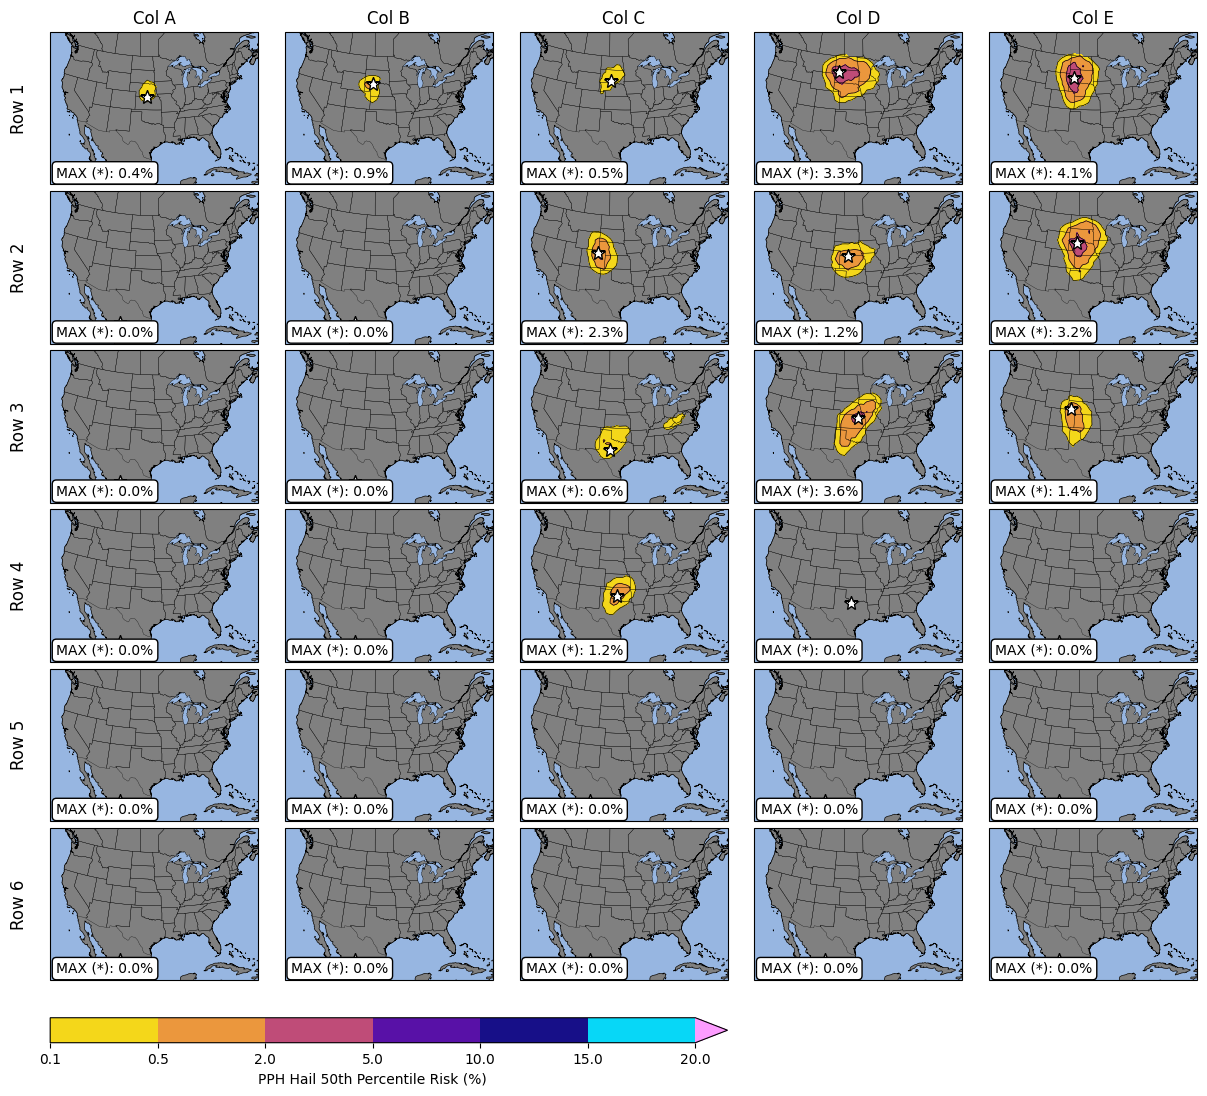

In [34]:
percentile = 0.5
plot_pper_stamps(som_ds, 'percentile', percentile, risk_colors, risk_levels)

plt.savefig(f'./Figures/{int(100*percentile)}_percentile_hail_nodes.png', dpi= 300, bbox_inches= 'tight')
plt.show()

# 75th PERCENTILE:


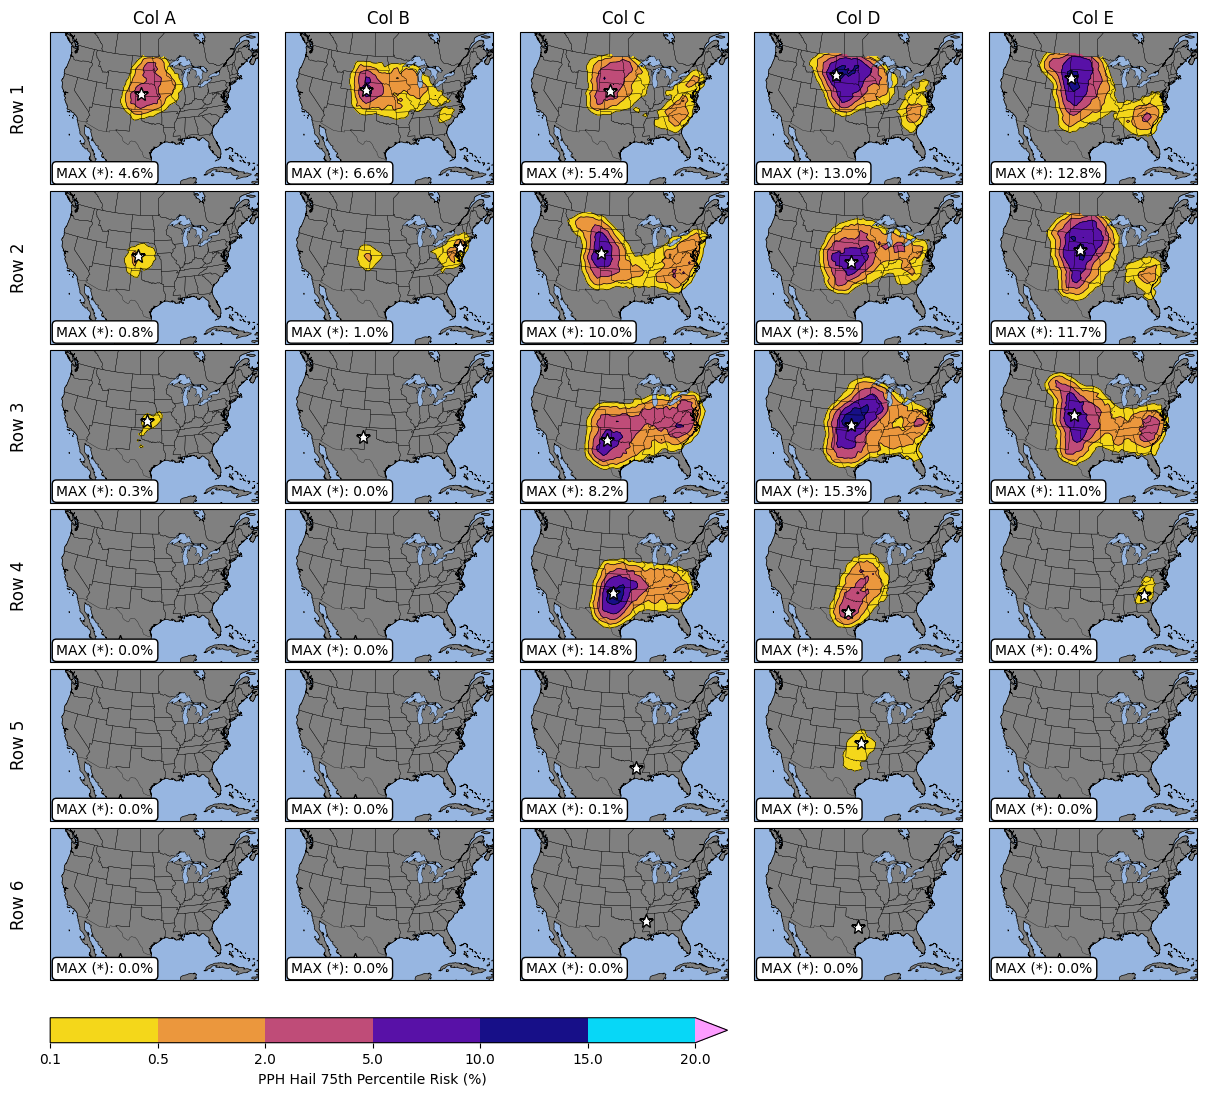

In [35]:
percentile = 0.75
plot_pper_stamps(som_ds, 'percentile', percentile, risk_colors, risk_levels)

plt.savefig(f'./Figures/{int(100*percentile)}_percentile_hail_nodes.png', dpi= 300, bbox_inches= 'tight')
plt.show()

# 95th PERCENTILE:

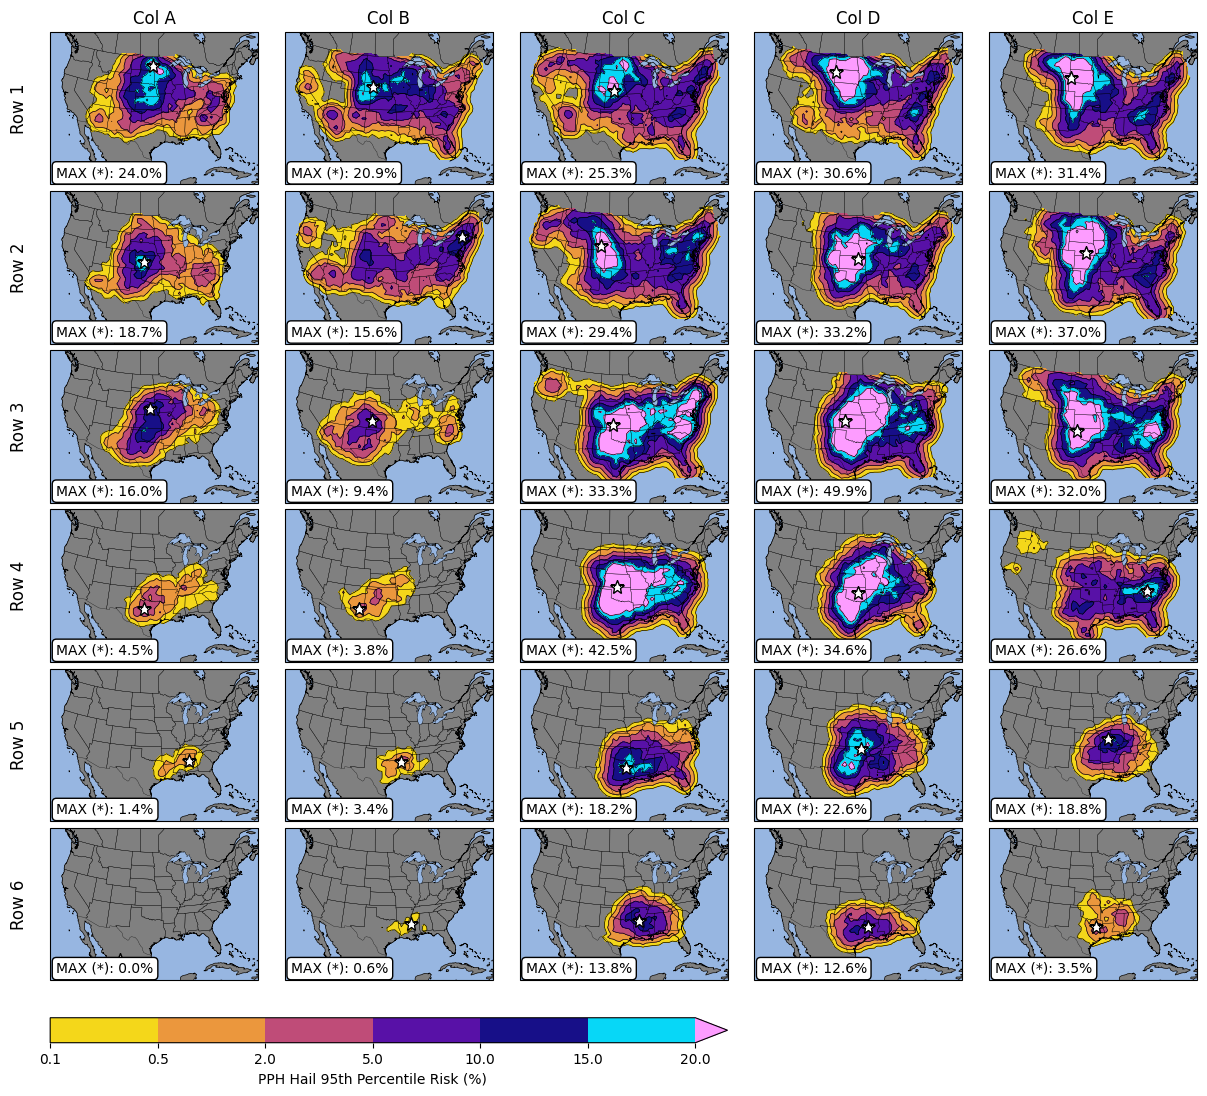

In [36]:
percentile = 0.95
plot_pper_stamps(som_ds, 'percentile', percentile, risk_colors, risk_levels)


plt.savefig(f'./Figures/{int(100*percentile)}_percentile_hail_nodes.png', dpi= 300, bbox_inches= 'tight')
plt.show()

# Frequency of Exceedance:

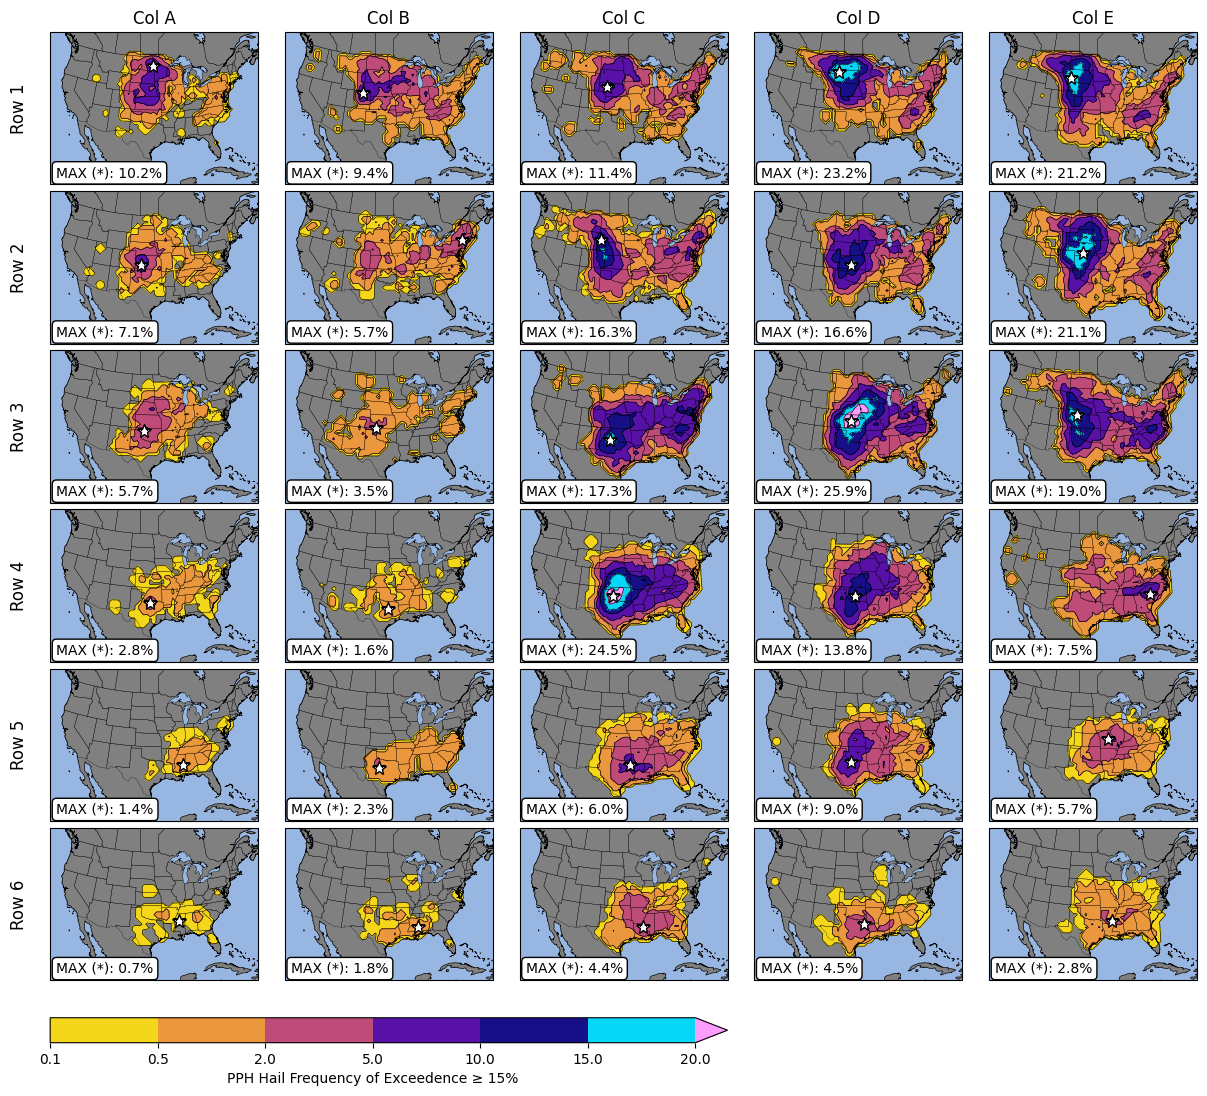

In [54]:
plot_pper_stamps(som_ds, 'foe', 15, risk_colors, risk_levels)


plt.savefig('./Figures/15_foe_hail_nodes', dpi= 300, bbox_inches= 'tight')
plt.show()

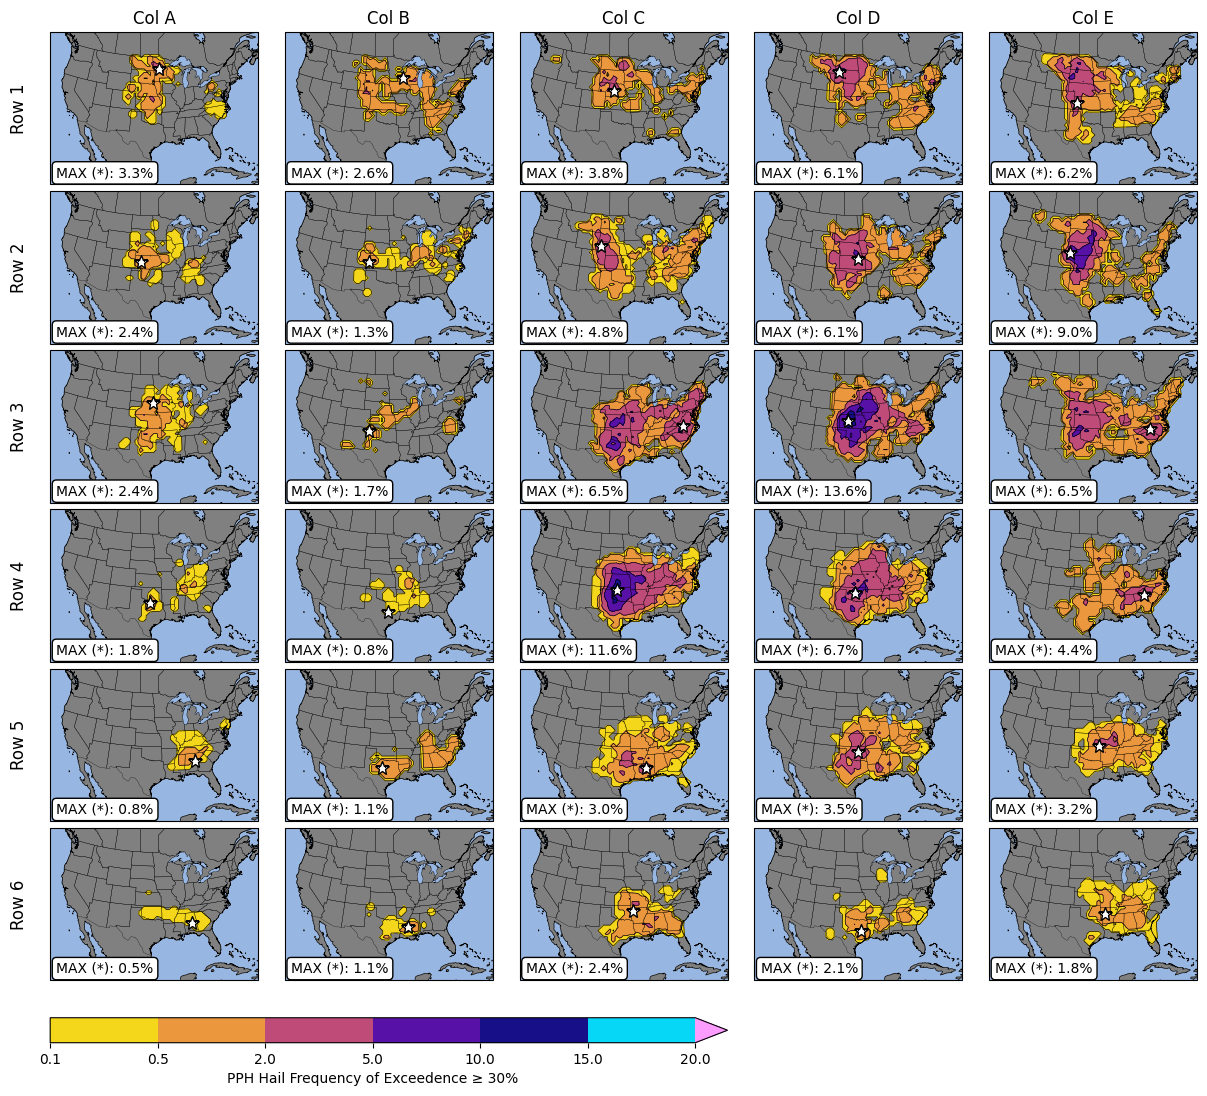

In [39]:
plot_pper_stamps(som_ds, 'foe', 30, risk_colors, risk_levels)

plt.savefig('./Figures/30_foe_haial_nodes.png', dpi= 300, bbox_inches= 'tight')
plt.show()

## Test Plots:

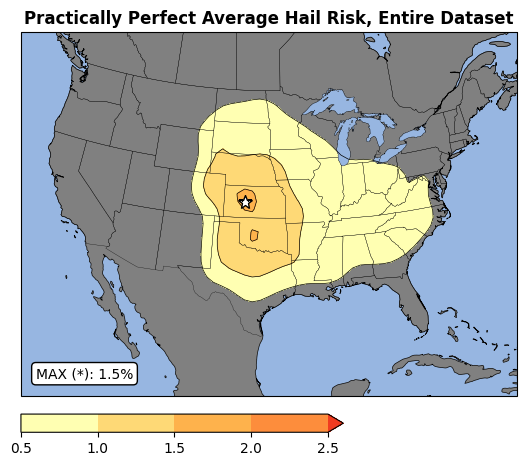

In [40]:
hail_mean = ds_hail.mean(dim= 'time')
plot_pper_contour(hail_mean, 'Practically Perfect Average Hail Risk, Entire Dataset', mean_colors, mean_levels)

plt.savefig('./Figures/hail_avg_pp_risk_entire.png', dpi= 300, bbox_inches= 'tight')
plt.show()

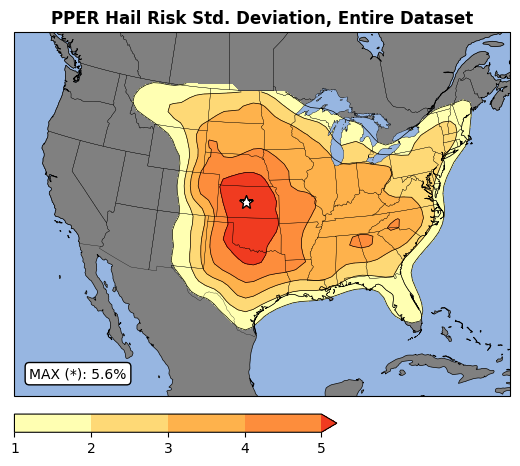

In [41]:
hail_std = ds_hail.std(dim= 'time')
plot_pper_contour(hail_std, 'PPER Hail Risk Std. Deviation, Entire Dataset', foe_colors, np.arange(1, 6, 1))

plt.savefig('./Figures/hail_stdev_pp_risk_entire.png', dpi= 300, bbox_inches= 'tight')

In [42]:
threshold= 15
arr_15 = ds_hail.where(ds_hail >= threshold) * 0 + 1
sum_15 = arr_15.sum(axis= 0)
freq_15 = sum_15 / counts * 100

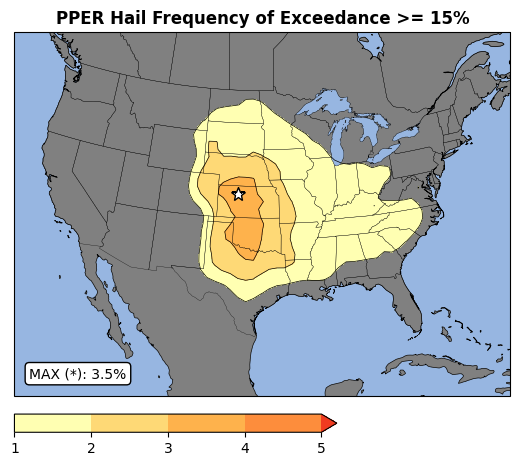

In [43]:
plot_pper_contour(freq_15, 'PPER Hail Frequency of Exceedance >= 15%', foe_colors, foe_15)
plt.savefig('./Figures/PPER_FOE_15.png', dpi= 300, bbox_inches= 'tight')
plt.show()

In [44]:
threshold= 5
arr_5 = ds_hail.where(ds_hail >= threshold) * 0 + 1
sum_5 = arr_5.sum(axis= 0)
freq_5 = sum_5 / counts * 100

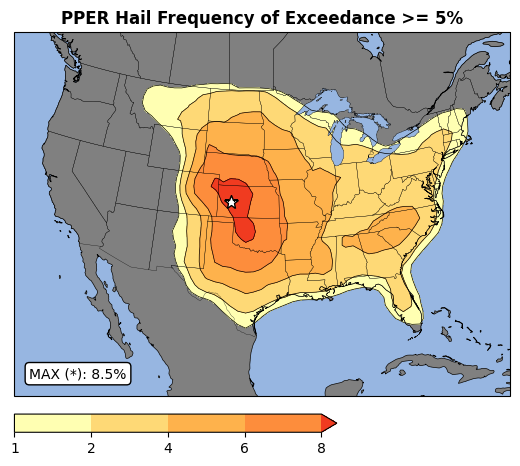

In [45]:
plot_pper_contour(freq_5, f'PPER Hail Frequency of Exceedance >= {threshold}%', foe_colors, foe_5)
plt.savefig('./Figures/PPER_FOE_5.png', dpi= 300, bbox_inches= 'tight')